# Catalogue Comparison (SARAH)

## Research Question

<mark>How consistent are the age and metallicity measurements between VandenBerg and Krause, and could catalogue choice affect which clusters appear unusual?<mark>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv("../data/cleaned/globular_clusters_cleaned.csv")

Check data was loaded correctly:

In [3]:
print (data.shape)
data.head()

(55, 38)


,FeH,Age,Age_err,Method,Figs,Range,HBtype,R_G,M_V,v_e0,...,r_h,mu_V,rho_0,lg_tc,lg_th,Mstar,rh,C5,Age_Krause,FeH_Krause
0,-0.76,11.75,0.25,V,14,11.50–11.75,-0.99,7.4,-9.42,54.8,...,3.17,14.38,4.88,7.84,9.55,6.46,7.10,0.92,12.80,-0.76
1,-1.32,11.50,0.38,H,24,NaN,0.98,12.0,-6.75,10.9,...,2.23,20.05,1.78,8.99,9.32,0.46,9.80,0.05,12.20,-1.32
2,-1.30,10.75,0.25,V,13,10.75–11.00,-0.87,9.4,-8.43,44.4,...,0.82,14.80,4.74,7.76,8.93,2.50,3.50,0.72,10.00,-1.26
3,-1.27,10.75,0.25,V,13,10.75–11.25,-0.71,18.1,-7.80,23.6,...,0.68,17.73,2.99,8.59,9.12,3.41,5.50,0.62,10.24,-1.08
4,-1.18,11.00,0.25,V,13,10.75–11.25,-0.32,16.6,-8.33,47.6,...,0.51,14.25,5.09,7.43,8.82,5.51,3.05,1.81,7.64,-1.13


## Selecting Clusters with Measurements in VandenBerg and Krause

Only clusters with both VandenBerg and Krause age and metallicity measurements are included in the direct catalogue comparison (3/55 VandenBerg Clusters were excluded). 

`data.dropna(...)` - takes data and reomves rows containing missing values
`len(...)` - how many rows are in this data frame

In [5]:
comparison = data.dropna (
    subset = ["Age", "FeH", "Age_Krause", "FeH_Krause"]
)

print("Number of clusters in comparison:", len(comparison))

Number of clusters in comparison: 52


Check comparison is valid:

In [7]:
comparison[
    ["Cluster_ID", "Age", "Age_Krause", "FeH", "FeH_Krause"]
].head(10)

,Cluster_ID,Age,Age_Krause,FeH,FeH_Krause
0,NGC104,11.75,12.80,-0.76,-0.76
1,NGC288,11.50,12.20,-1.32,-1.32
2,NGC362,10.75,10.00,-1.30,-1.26
3,NGC1261,10.75,10.24,-1.27,-1.08
4,NGC1851,11.00,7.64,-1.18,-1.13
5,NGC2808,11.00,11.20,-1.18,-1.18
6,NGC3201,11.50,11.10,-1.51,-1.51
8,NGC4590,12.00,12.70,-2.27,-2.27
9,NGC4833,12.50,12.50,-1.89,-1.71
10,NGC5024,12.25,12.70,-2.06,-1.86


In [8]:
comparison = comparison.copy()

In [11]:
comparison ["Age_difference"] = (comparison ["Age_Krause"] - comparison ["Age"])
comparison ["FeH_difference"] = (comparison ["FeH_Krause"] - comparison ["FeH"])

comparison [["Cluster_ID", "Age", "Age_Krause", "Age_difference", "FeH", "FeH_Krause", "FeH_difference"]].head(10)

,Cluster_ID,Age,Age_Krause,Age_difference,FeH,FeH_Krause,FeH_difference
0,NGC104,11.75,12.80,1.05,-0.76,-0.76,0.00
1,NGC288,11.50,12.20,0.70,-1.32,-1.32,0.00
2,NGC362,10.75,10.00,-0.75,-1.30,-1.26,0.04
3,NGC1261,10.75,10.24,-0.51,-1.27,-1.08,0.19
4,NGC1851,11.00,7.64,-3.36,-1.18,-1.13,0.05
5,NGC2808,11.00,11.20,0.20,-1.18,-1.18,0.00
6,NGC3201,11.50,11.10,-0.40,-1.51,-1.51,0.00
8,NGC4590,12.00,12.70,0.70,-2.27,-2.27,0.00
9,NGC4833,12.50,12.50,0.00,-1.89,-1.71,0.18
10,NGC5024,12.25,12.70,0.45,-2.06,-1.86,0.20


## Age Comparison

VandenBerg and Krause age measurements are compared directly. A one-to-one line represents perfect agreement between the two catalogues. Clusters far from this line have larger differences between the two age estimates.

`plt.figure(figsize=(7, 6))` - creates new figure that is 7 inches wide and 6 inches tall

`plt.scatter( comparison["Age"], comparison["Age_Krause"])`- creates a scatter plot where VandenBerg Age is on the x-axis and Krause Age is on the y-axis. 



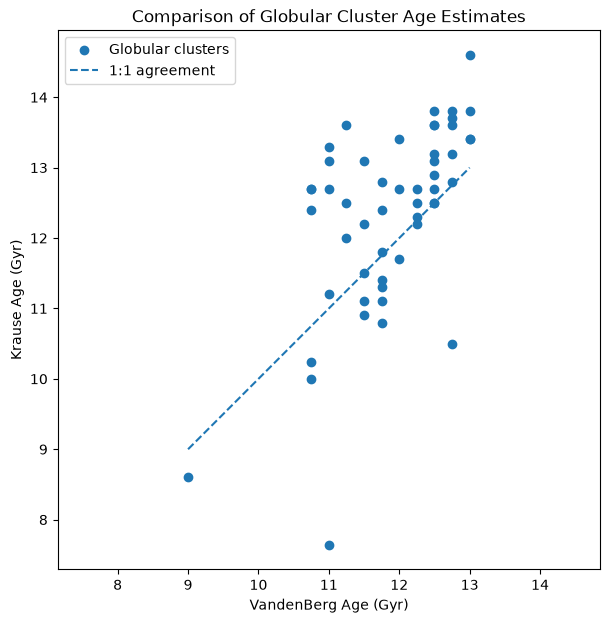

In [16]:
# Find the minimum and maximum age across BOTH catalogues
min_age = min(
    comparison["Age"].min(),
    comparison["Age_Krause"].min()
)

max_age = max(
    comparison["Age"].max(),
    comparison["Age_Krause"].max()
)

plt.figure(figsize=(7, 7))

plt.scatter(
    comparison["Age"],
    comparison["Age_Krause"],
    label = "Globular clusters"
)

plt.plot(
    [comparison["Age"].min(), comparison["Age"].max()],
    [comparison["Age"].min(), comparison["Age"].max()],
    linestyle = "--",
    label = "1:1 agreement"
)

plt.xlim(min_age, max_age)
plt.ylim(min_age, max_age)

plt.xlabel("VandenBerg Age (Gyr)")
plt.ylabel("Krause Age (Gyr)")
plt.title("Comparison of Globular Cluster Age Estimates")

plt.legend()
plt.axis("equal")

plt.show()

Finding the absolute age difference to rank the difference from largest to biggest to identify outliers: 

In [18]:
comparison["Absolute_age_difference"] = comparison["Age_difference"].abs()

largest_age_difference = comparison.sort_values (
    "Absolute_age_difference", 
    ascending = False
)

largest_age_difference[
    ["Cluster_ID", "Age", "Age_Krause", "Age_difference", "Absolute_age_difference"]
].head(7)

,Cluster_ID,Age,Age_Krause,Age_difference,Absolute_age_difference
4,NGC1851,11.00,7.64,-3.36,3.36
25,NGC6304,11.25,13.60,2.35,2.35
29,NGC6366,11.00,13.30,2.30,2.30
32,NGC6535,12.75,10.50,-2.25,2.25
36,NGC6637,11.00,13.10,2.10,2.10
16,NGC5927,10.75,12.70,1.95,1.95
27,NGC6352,10.75,12.70,1.95,1.95


Label the largest age outliers: 

`.iterrows()` - gives Python each row of the data frame  
`_` - Python assigns a value  
`xytext` - moves text slightly away from the data point  

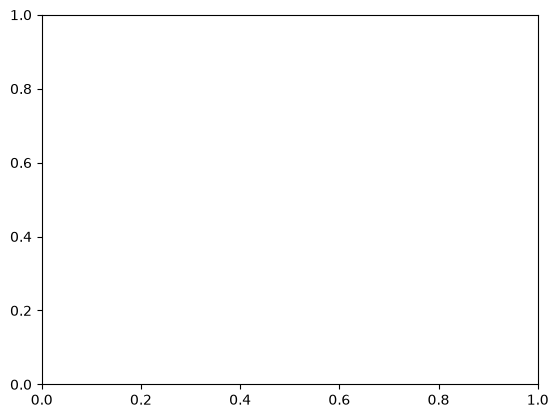

In [21]:
top_age_outliers = largest_age_difference.head(5)

for _, row in top_age_outliers.iterrows():
    plt.annotate(
        row["Cluster_ID"],
        (row["Age"], row["Age_Krause"]),
        xytext = (5, 5),
        textcoords = "offset points",
        fontsize = 9
    )